#### 本教程演示了如何使用Adversarial Debiasing算法来学习公平的分类器。

对抗性去偏见，Adversarial debiasing[1]是一种处理中技术，此方法通过学习分类器来最大限度地提高预测准确性，同时降低对手从预测中确定受保护属性的能力。这种方法可以得到一个公平的分类器，因为预测不可能携带任何可被对手利用的群体歧视信息。在这个教程中，你将了解如何使用这种算法来学习有公平性约束和无公平性约束的模型，并将它们应用于 Adult 数据集。

In [1]:
%matplotlib inline

# 加载需要的库
import sys
sys.path.append("../")
from aif360.datasets import BinaryLabelDataset
from aif360.datasets import AdultDataset, GermanDataset, CompasDataset
from aif360.datasets import DuolingoDataset

from aif360.datasets import StuperDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.metrics import ClassificationMetric
from aif360.metrics.utils import compute_boolean_conditioning_vector

from aif360.algorithms.preprocessing.optim_preproc_helpers.data_preproc_functions import load_preproc_data_adult, load_preproc_data_compas, load_preproc_data_german
from aif360.algorithms.preprocessing.optim_preproc_helpers.data_preproc_functions import  load_preproc_data_stuper
from aif360.algorithms.preprocessing.optim_preproc_helpers.data_preproc_functions import load_preproc_data_duolingo

from aif360.algorithms.inprocessing.adversarial_debiasing import AdversarialDebiasing

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score

from IPython.display import Markdown, display
import matplotlib.pyplot as plt

import tensorflow.compat.v1 as tf
tf.disable_eager_execution()

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html


#### 读取数据集和设置选项

In [2]:
# 获取数据集，进行训练集和测试集的划分
dataset_orig = load_preproc_data_stuper()

privileged_groups = [{'sex': 1}]
unprivileged_groups = [{'sex': 0}]

dataset_orig_train, dataset_orig_test = dataset_orig.split([0.9], shuffle=False)

In [3]:
# 打印出数据集的一些特征
display(Markdown("#### Training Dataset shape"))
print(dataset_orig_train.features.shape)
display(Markdown("#### Favorable and unfavorable labels"))
print(dataset_orig_train.favorable_label, dataset_orig_train.unfavorable_label)
display(Markdown("#### Protected attribute names"))
print(dataset_orig_train.protected_attribute_names)
display(Markdown("#### Privileged and unprivileged protected attribute values"))
print(dataset_orig_train.privileged_protected_attributes, 
      dataset_orig_train.unprivileged_protected_attributes)
display(Markdown("#### Dataset feature names"))
print(dataset_orig_train.feature_names)

#### Training Dataset shape

(584, 41)


#### Favorable and unfavorable labels

1.0 0.0


#### Protected attribute names

['sex']


#### Privileged and unprivileged protected attribute values

[array([1.])] [array([0.])]


#### Dataset feature names

['sex', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'schoolsup_encoded', 'famsup_encoded', 'paid_encoded', 'activities_encoded', 'nursery_encoded', 'higher_encoded', 'internet_encoded', 'romantic_encoded', 'school_MS', 'address_U', 'famsize_LE3', 'Pstatus_T', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher']


#### 原始训练数据的指标

In [4]:
# 原始数据集的指标
metric_orig_train = BinaryLabelDatasetMetric(dataset_orig_train, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)
display(Markdown("#### Original training dataset"))
print("Train set: Difference in mean outcomes between unprivileged and privileged groups = %f" % metric_orig_train.mean_difference())
metric_orig_test = BinaryLabelDatasetMetric(dataset_orig_test, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)
print("Test set: Difference in mean outcomes between unprivileged and privileged groups = %f" % metric_orig_test.mean_difference())

#### Original training dataset

Train set: Difference in mean outcomes between unprivileged and privileged groups = -0.151784
Test set: Difference in mean outcomes between unprivileged and privileged groups = -0.052296


In [5]:
min_max_scaler = MaxAbsScaler()
dataset_orig_train.features = min_max_scaler.fit_transform(dataset_orig_train.features)
dataset_orig_test.features = min_max_scaler.transform(dataset_orig_test.features)
metric_scaled_train = BinaryLabelDatasetMetric(dataset_orig_train, 
                             unprivileged_groups=unprivileged_groups,
                             privileged_groups=privileged_groups)
# 缩放数据集 - 验证缩放是否不会影响组标签统计数据
display(Markdown("#### Scaled dataset - Verify that the scaling does not affect the group label statistics"))
print("Train set: Difference in mean outcomes between unprivileged and privileged groups = %f" % metric_scaled_train.mean_difference())
metric_scaled_test = BinaryLabelDatasetMetric(dataset_orig_test, 
                             unprivileged_groups=unprivileged_groups,
                             privileged_groups=privileged_groups)
print("Test set: Difference in mean outcomes between unprivileged and privileged groups = %f" % metric_scaled_test.mean_difference())


#### Scaled dataset - Verify that the scaling does not affect the group label statistics

Train set: Difference in mean outcomes between unprivileged and privileged groups = -0.151784
Test set: Difference in mean outcomes between unprivileged and privileged groups = -0.052296


### 应用基于Adversarial Debiasing的处理中算法

In [6]:
# Learn parameters with debias set to True
# 在去偏见设置为True时学习参数
sess = tf.Session()
debiased_model = AdversarialDebiasing(privileged_groups = privileged_groups,
                          unprivileged_groups = unprivileged_groups,
                          scope_name='debiased_classifier',
                          debias=True,
                          sess=sess)

In [7]:
debiased_model.fit(dataset_orig_train)

诊断 - 所有可训练变量:
变量: debiased_classifier/classifier_model_gate/dense/kernel:0
变量: debiased_classifier/classifier_model_gate/dense/bias:0
变量: debiased_classifier/classifier_model_gate/dense_1/kernel:0
变量: debiased_classifier/classifier_model_gate/dense_1/bias:0
变量: debiased_classifier/classifier_model_expert_0/dense_2/kernel:0
变量: debiased_classifier/classifier_model_expert_0/dense_2/bias:0
变量: debiased_classifier/classifier_model_expert_0/dense_3/kernel:0
变量: debiased_classifier/classifier_model_expert_0/dense_3/bias:0
变量: debiased_classifier/classifier_model_expert_0/dense_4/kernel:0
变量: debiased_classifier/classifier_model_expert_0/dense_4/bias:0
变量: debiased_classifier/classifier_model_expert_1/dense_5/kernel:0
变量: debiased_classifier/classifier_model_expert_1/dense_5/bias:0
变量: debiased_classifier/classifier_model_expert_1/dense_6/kernel:0
变量: debiased_classifier/classifier_model_expert_1/dense_6/bias:0
变量: debiased_classifier/classifier_model_expert_1/dense_7/kernel:0
变量: debiased_cl

In [8]:
# 将朴素模型应用于测试数据
dataset_debiasing_train = debiased_model.predict(dataset_orig_train)
dataset_debiasing_test = debiased_model.predict(dataset_orig_test)

Feature Importance in Student Dataset（去偏见模型）


Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from current font.
Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from current font.
Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from current font.
Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from current font.
Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from current font.
Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from current font.
Glyph 35265 (\N{CJK UNIFIED IDEOGRAPH-89C1}) missing from current font.
Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from current font.
Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from curre

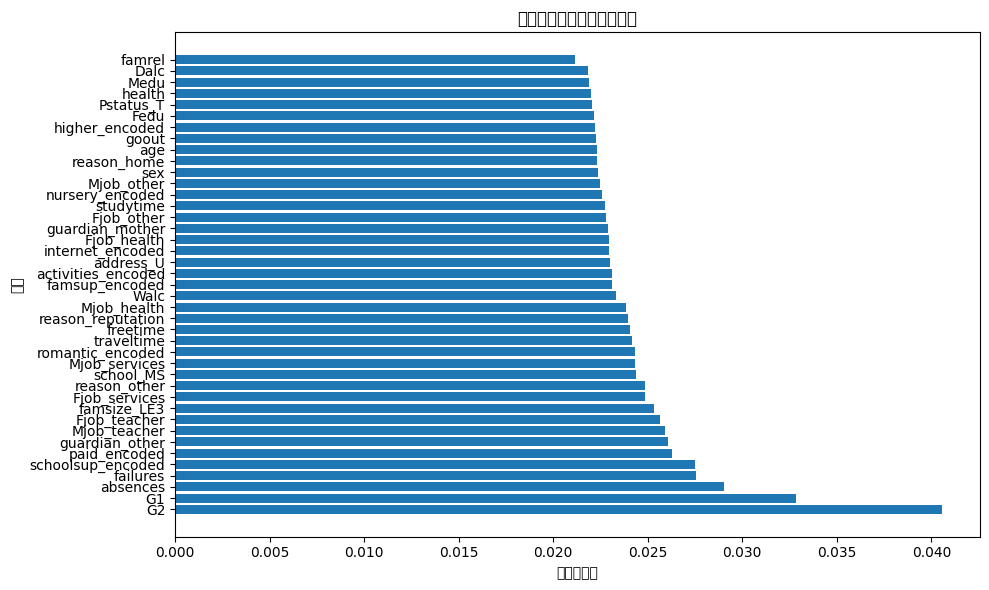

Glyph 19987 (\N{CJK UNIFIED IDEOGRAPH-4E13}) missing from current font.
Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from current font.
Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from current font.
Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from current font.
Glyph 35265 (\N{CJK UNIFIED IDEOGRAPH-89C1}) missing from current font.
Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from current font.
Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from current font.
Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from current font.
Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from current font.
Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from current font.
Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from current font.
Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from curren

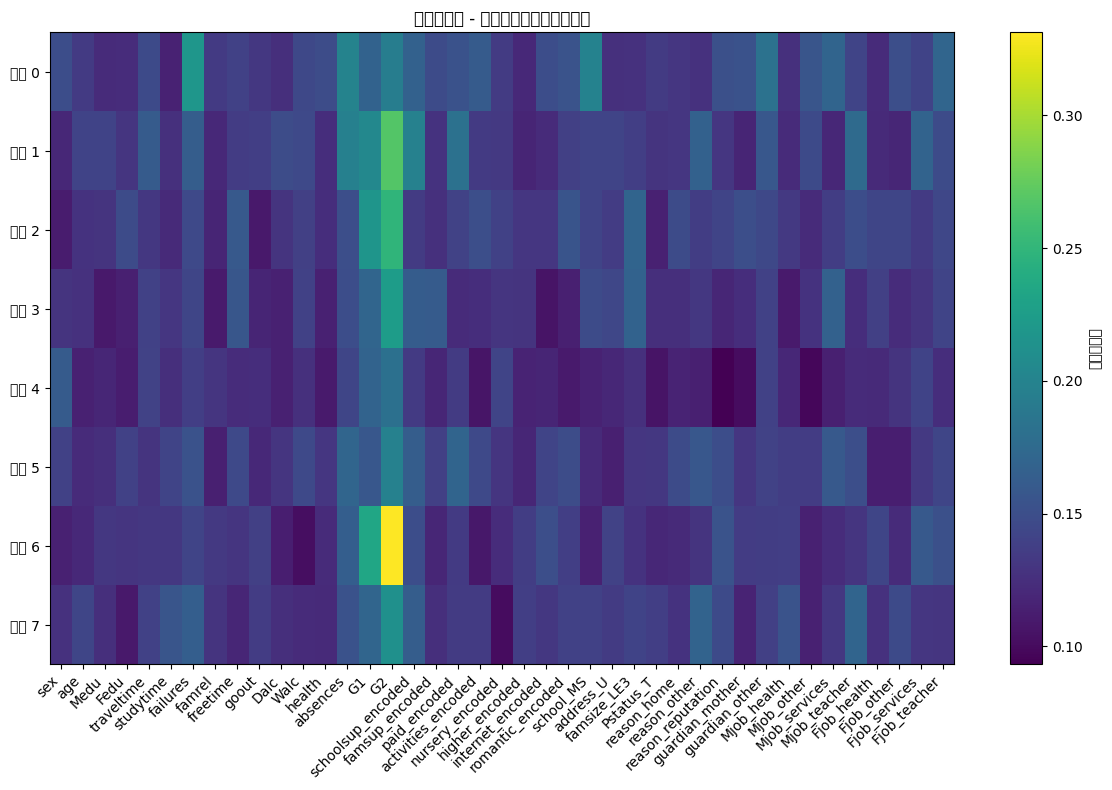

In [14]:
# 对去偏见模型也做同样的分析
print("Feature Importance in Student Dataset（去偏见模型）")
feature_importance_debiased = debiased_model.get_feature_importance(dataset_orig_train)

# 排序并可视化
sorted_importance_debiased = sorted(feature_importance_debiased, key=lambda x: x[1], reverse=True)
feature_names_debiased = [x[0] for x in sorted_importance_debiased]
importance_values_debiased = [x[1] for x in sorted_importance_debiased]

plt.figure(figsize=(10, 6))
plt.barh(feature_names_debiased, importance_values_debiased)
plt.xlabel('重要性分数')
plt.ylabel('特征')
plt.title('特征重要性（去偏见模型）')
plt.tight_layout()
plt.show()

# 可视化每个专家网络对每个特征的活跃程度
def visualize_expert_importance(model, dataset, title):
    import numpy as np 
    expert_importance = model.analyze_expert_weights()
    feature_names = dataset.feature_names
    
    if not expert_importance or not any(expert_importance):
        print(f"警告：无法获取{title}的专家网络重要性")
        return
    
    # 只使用第一层权重分析特征重要性
    expert_first_layer = []
    for expert_id, expert_layers in enumerate(expert_importance):
        if expert_layers:
            expert_first_layer.append(expert_layers[0])
        else:
            # 如果该专家没有权重，用零填充
            expert_first_layer.append(np.zeros(len(feature_names)))
    
    # 创建热图
    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    im = ax.imshow(expert_first_layer, aspect='auto', cmap='viridis')
    
    # 设置坐标轴
    ax.set_xticks(np.arange(len(feature_names)))
    ax.set_yticks(np.arange(len(expert_importance)))
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
    ax.set_yticklabels([f'专家 {i}' for i in range(len(expert_importance))])
    
    # 添加颜色条
    plt.colorbar(im, ax=ax, label='特征重要性')
    
    # 设置标题和标签
    plt.title(f'{title} - 专家网络特征重要性热图')
    plt.tight_layout()
    plt.show()

# 可视化两个模型的专家网络特征重要性
visualize_expert_importance(debiased_model, dataset_orig_train, "debias model")

In [10]:
# # 去偏见的模型数据集的度量指标
display(Markdown("#### Model - with debiasing - dataset metrics"))
metric_dataset_debiasing_train = BinaryLabelDatasetMetric(dataset_debiasing_train, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)

print("Train set: Difference in mean outcomes between unprivileged and privileged groups = %f" % metric_dataset_debiasing_train.mean_difference())

metric_dataset_debiasing_test = BinaryLabelDatasetMetric(dataset_debiasing_test, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)

print("Test set: Difference in mean outcomes between unprivileged and privileged groups = %f" % metric_dataset_debiasing_test.mean_difference())




display(Markdown("#### Model - with debiasing - classification metrics"))
classified_metric_debiasing_test = ClassificationMetric(dataset_orig_test, 
                                                 dataset_debiasing_test,
                                                 unprivileged_groups=unprivileged_groups,
                                                 privileged_groups=privileged_groups)
print("Test set: Classification accuracy = %f" % classified_metric_debiasing_test.accuracy())
TPR = classified_metric_debiasing_test.true_positive_rate()
TNR = classified_metric_debiasing_test.true_negative_rate()
bal_acc_debiasing_test = 0.5*(TPR+TNR)

print("Test set: Statistical parity difference = %f" % classified_metric_debiasing_test.statistical_parity_difference())
print("Test set: Equalized Odds difference = %f" % classified_metric_debiasing_test.equalized_odds_difference())
print("Test set: Equal opportunity difference = %f" % classified_metric_debiasing_test.equal_opportunity_difference())
print("Test set: Disparate impact = %f" % classified_metric_debiasing_test.disparate_impact())

#### Model - with debiasing - dataset metrics

Train set: Difference in mean outcomes between unprivileged and privileged groups = -0.157772
Test set: Difference in mean outcomes between unprivileged and privileged groups = -0.116071


#### Model - with debiasing - classification metrics

Test set: Classification accuracy = 0.892308
Test set: Statistical parity difference = -0.116071
Test set: Equalized Odds difference = -0.119048
Test set: Equal opportunity difference = -0.000000
Test set: Disparate impact = 0.729167
